/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


СТАТИСТИКА

Исторические данные:
  Период: 2015-01 - 2025-03
  Среднее: 11361
  Минимум: 6611
  Максимум: 14857

Прогноз на 12 месяцев:
  Средний прогноз: 8799
  Минимум: 7914
  Максимум: 9866
  Тренд: падение


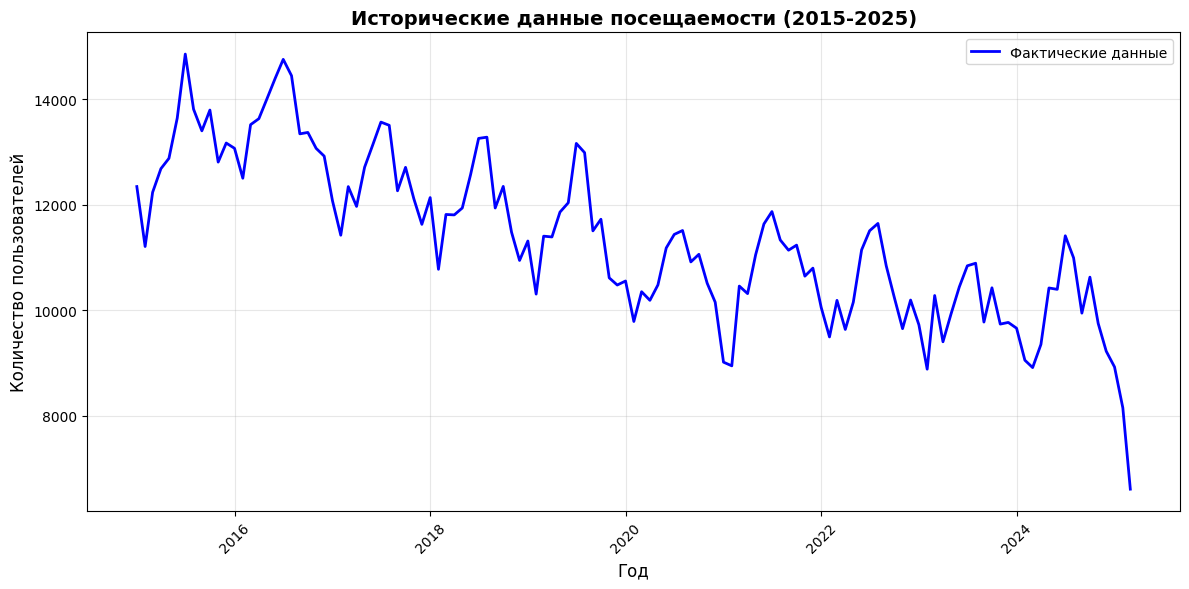

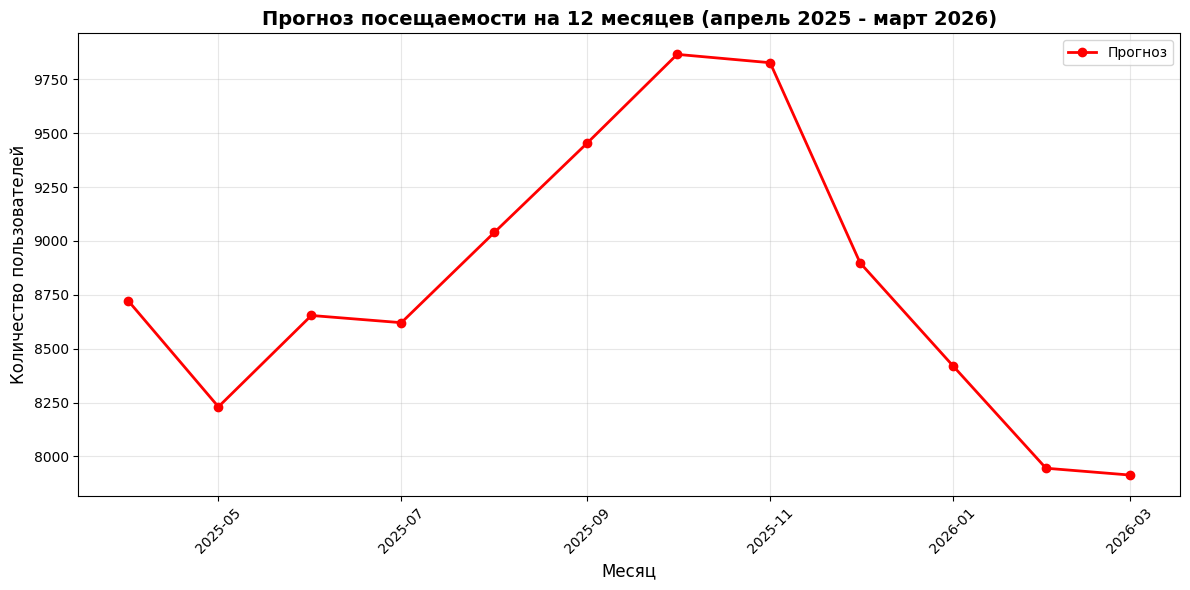

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

#Загрузка данных для анализа
df = pd.read_csv('newborns_stats.csv')
df['date'] = pd.to_datetime(df[['year', 'month']].assign(day=1))
df = df.sort_values('date')


df['month_num'] = (df['year'] - 2015) * 12 + df['month']

#Обучаем модель
X = df[['month_num']]
y = df['target']

model = LinearRegression()
model.fit(X, y)

#Построение прогноза
last_month_num = df['month_num'].max()
future_months = np.arange(last_month_num + 1, last_month_num + 13).reshape(-1, 1)
predictions = model.predict(future_months)


seasonality = [0.95, 0.90, 0.95, 0.95, 1.00, 1.05, 1.10, 1.10, 1.00, 0.95, 0.90, 0.90]
predictions = predictions * np.array(seasonality)

# Даты для прогноза
future_dates = pd.date_range(start='2025-04-01', periods=12, freq='MS')

#График №1 - исторические данные
plt.figure(figsize=(12, 6))
plt.plot(df['date'], df['target'], 'b-', linewidth=2, label='Фактические данные')
plt.title('Исторические данные посещаемости (2015-2025)', fontsize=14, fontweight='bold')
plt.xlabel('Год', fontsize=12)
plt.ylabel('Кол-во пользователей', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('history_only.png', dpi=300)

#График №2 - прогноз на следующий год
plt.figure(figsize=(12, 6))
plt.plot(future_dates, predictions, 'r-o', linewidth=2, markersize=6, label='Прогноз')
plt.title('Прогноз посещаемости на 12 месяцев',
          fontsize=14, fontweight='bold')
plt.xlabel('Месяц', fontsize=12)
plt.ylabel('Кол-во пользователей', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('forecast_only.png', dpi=300)

#Общая статистика
print("СТАТИСТИКА:")
print(f"\nИсторические данные:")
print(f"  Период: {df['date'].min().strftime('%Y-%m')} - {df['date'].max().strftime('%Y-%m')}")
print(f"  Среднее: {df['target'].mean():.0f}")
print(f"  Минимум: {df['target'].min()}")
print(f"  Максимум: {df['target'].max()}")

print(f"\nПрогноз на 12 месяцев:")
print(f"  Средний прогноз: {predictions.mean():.0f}")
print(f"  Минимум: {predictions.min():.0f}")
print(f"  Максимум: {predictions.max():.0f}")
print(f"  Тренд: {'рост' if predictions[-1] > predictions[0] else 'падение'}")
